In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from IQT import *

import IQT.util

import tensorflow as tf

2024-02-05 17:46:02.726479: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-02-05 17:46:02.755220: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-05 17:46:02.755242: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-05 17:46:02.756580: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-05 17:46:02.763570: I tensorflow/core/platform/cpu_feature_guar

In [2]:
test_data = data_loader.DataLoader(data_dir="../data",
                                   subject_labels=['100307'],
                                   subdir='LR',
                                   file_head='dt_b1000_lowres_4_',
                                   # file_head='dt_b1000_',
                                   normalization_method='stdscore',
                                   mode='dti')

test_data_t1 = data_loader.DataLoader(data_dir="../data",
                                      subject_labels=['100307'],
                                      subdir='T1w',
                                      file_head='T1w_acpc_dc_restore_brain',
                                      normalization_method='stdscore',
                                      mode='T1w')


In [3]:
target_data = IQT.util.load_dtis("../data/100307/HR/", "dt_b1000_")

In [4]:
target_tensors = target_data[..., 2:]

norm_metrics_target = IQT.util.apply_normalization(target_tensors, target_data[..., 0]==0, 'stdscore')

target_tensors.shape

(145, 174, 145, 6)

In [5]:
run_indices = test_data.get_grid_indices(0, 8, 8, overlap=3)

run_indices

[(9, 9, 9),
 (23, 9, 9),
 (37, 9, 9),
 (51, 9, 9),
 (65, 9, 9),
 (79, 9, 9),
 (93, 9, 9),
 (107, 9, 9),
 (121, 9, 9),
 (135, 9, 9),
 (9, 23, 9),
 (23, 23, 9),
 (37, 23, 9),
 (51, 23, 9),
 (65, 23, 9),
 (79, 23, 9),
 (93, 23, 9),
 (107, 23, 9),
 (121, 23, 9),
 (135, 23, 9),
 (9, 37, 9),
 (23, 37, 9),
 (37, 37, 9),
 (51, 37, 9),
 (65, 37, 9),
 (79, 37, 9),
 (93, 37, 9),
 (107, 37, 9),
 (121, 37, 9),
 (135, 37, 9),
 (9, 51, 9),
 (23, 51, 9),
 (37, 51, 9),
 (51, 51, 9),
 (65, 51, 9),
 (79, 51, 9),
 (93, 51, 9),
 (107, 51, 9),
 (121, 51, 9),
 (135, 51, 9),
 (9, 65, 9),
 (23, 65, 9),
 (37, 65, 9),
 (51, 65, 9),
 (65, 65, 9),
 (79, 65, 9),
 (93, 65, 9),
 (107, 65, 9),
 (121, 65, 9),
 (135, 65, 9),
 (9, 79, 9),
 (23, 79, 9),
 (37, 79, 9),
 (51, 79, 9),
 (65, 79, 9),
 (79, 79, 9),
 (93, 79, 9),
 (107, 79, 9),
 (121, 79, 9),
 (135, 79, 9),
 (9, 93, 9),
 (23, 93, 9),
 (37, 93, 9),
 (51, 93, 9),
 (65, 93, 9),
 (79, 93, 9),
 (93, 93, 9),
 (107, 93, 9),
 (121, 93, 9),
 (135, 93, 9),
 (9, 107, 9),
 (

In [6]:
test_data.shape(0)

(145, 174, 145)

In [7]:
recon_model = np.zeros(test_data.shape(0) + (6,))

overlap_map = np.zeros(test_data.shape(0) + (1,))

for (i, j, k) in run_indices:
    
    recon_model[i-8:i+8,
                j-8:j+8,
                k-8:k+8] += test_data.get_patch(0, [i, j, k], 16).numpy()
    
    overlap_map[i-8:i+8,
                j-8:j+8,
                k-8:k+8] += 1
    
overlap_map[overlap_map == 0] = 1
    
recon_model = recon_model / overlap_map


2024-02-05 17:46:19.206137: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-05 17:46:19.341720: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-05 17:46:19.341798: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-05 17:46:19.343663: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-05 17:46:19.343697: I external/local_xla/xla/stream_executor

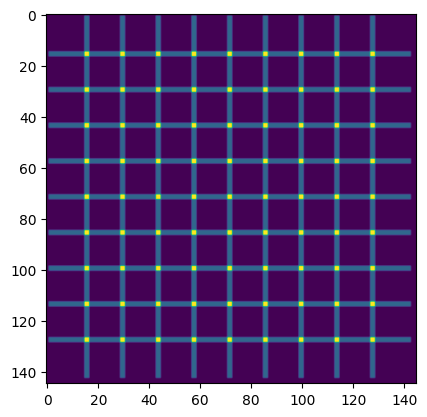

In [8]:
plt.imshow(overlap_map[:, 60, :])

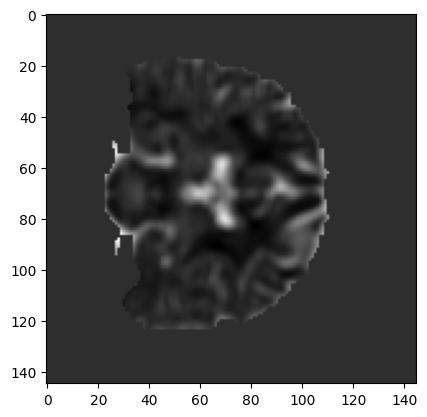

In [9]:
plt.imshow(recon_model[:, 80, :, 0], cmap='gray')

In [10]:
# model: keras.Model = models.simple_generator(input_ch=6, output_ch=6, layer_num=1, ipatch_size=11)
# model: keras.Model = models.vdsr(15)
# model: keras.Model = models.vdsr_t1(15, 27)
model: keras.Model = models.unet3d(16)

model.load_weights(filepath="../output/UNet_NoT1/Run25")

In [11]:
model_output = np.zeros(test_data.shape(0)+ (6,))

# model_output = model(recon_model[None,...])[0,...].numpy()

for (i, j, k) in run_indices:

    model_output[i-8:i+8,
                 j-8:j+8,
                 k-8:k+8] += model([test_data.get_patch(0, [i,
                                                            j,
                                                            k], 16)[None,...],
                                    test_data_t1.get_patch(0, [round(i * 1.25/0.7),
                                                               round(j * 1.25/0.7),
                                                               round(k * 1.25/0.7)], 32)[None,...]]).numpy()[0]
    

model_output = model_output / overlap_map


2024-02-05 17:46:21.763024: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2024-02-05 17:46:21.945129: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-05 17:46:22.159393: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [12]:
model_output.shape

(145, 174, 145, 6)

In [13]:
model_output[target_data[..., 0] != 0, :] = 0
recon_model[target_data[...,0] != 0, :] = 0
target_tensors[target_data[...,0] != 0, :] = 0

In [14]:
# print(model_output[40:60,40:60, 60, 3])

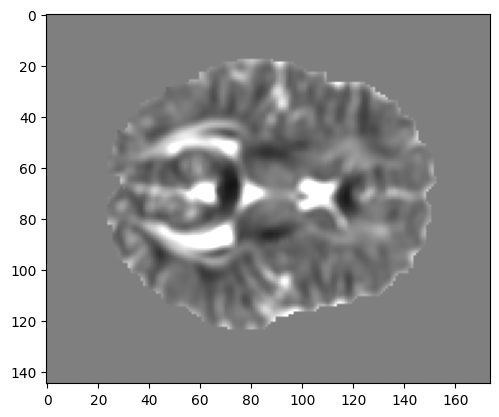

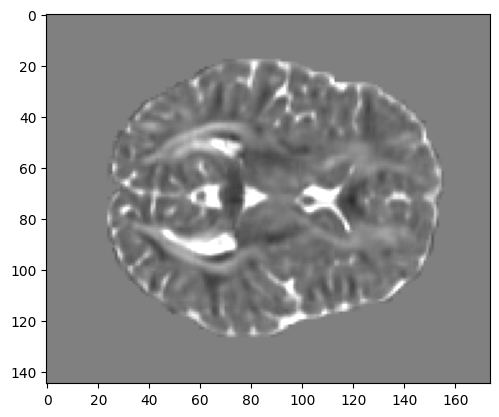

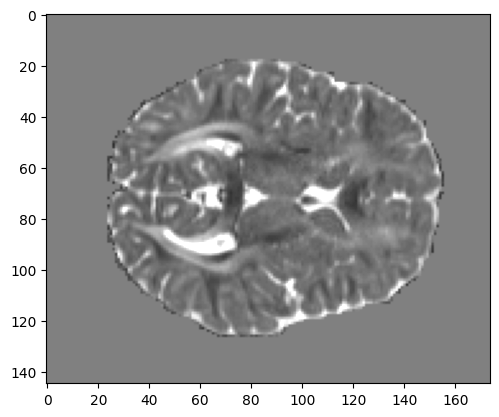

In [15]:
plt.imshow(recon_model[:, :, 60, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()
plt.imshow(model_output[:, :, 60, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()
plt.imshow(target_tensors[:, :, 60, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()

0.906991663509134


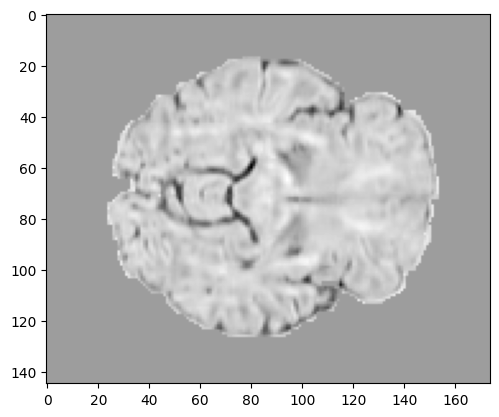

In [16]:
plt.imshow(target_data[:, :, 50, 0] - model_output[:, :, 50, 0], cmap='gray')

print(np.mean(np.square(target_data[:, :, 60, 0] - model_output[:, :, 60, 0])))